# K-Means Clustering of Customers

Practice activity from Microsoft *Foundations of AI and Machine Learning* — Module: AI/ML Algorithms and Techniques.

Goal: cluster customers by annual income and spending score, visualize the result, and use the elbow method to find a sensible number of clusters.

## 2. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 3. Load the dataset

41 'normal' customers with incomes from 15k to 35k in 0.5 steps, plus 3 high-income outliers at 80k/85k/90k. Spending scores are constructed so the normal customers split into a low-spending half and a high-spending half — natural ground truth for a 3-cluster solution.

In [2]:
annual_income = [
    15, 15.5, 16, 16.5, 17, 17.5, 18, 18.5, 19, 19.5,
    20, 20.5, 21, 21.5, 22, 22.5, 23, 23.5, 24, 24.5,
    25, 25.5, 26, 26.5, 27, 27.5, 28, 28.5, 29, 29.5,
    30, 30.5, 31, 31.5, 32, 32.5, 33, 33.5, 34, 34.5,
    35,
    80, 85, 90,  # outliers
]

spending_score = [
    # Low spenders (paired with the first 20 normal incomes)
    20, 25, 22, 18, 30, 28, 35, 33, 26, 31,
    24, 27, 29, 23, 21, 19, 32, 34, 36, 38,
    # High spenders (paired with the next 21 normal incomes)
    65, 70, 68, 72, 75, 80, 78, 82, 77, 83,
    85, 79, 81, 86, 88, 73, 76, 84, 87, 89, 90,
    # Outliers' spending scores
    95, 5, 50,
]

df = pd.DataFrame({
    'AnnualIncome':  annual_income,
    'SpendingScore': spending_score,
})
df.head()

,AnnualIncome,SpendingScore
0,15.0,20
1,15.5,25
2,16.0,22
3,16.5,18
4,17.0,30


## 4. Preprocess — scale the features

K-means minimizes squared **Euclidean** distance, so any feature with a larger numeric range dominates the others. `StandardScaler` rescales each feature to zero mean and unit variance so both contribute equally.

In [3]:
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled_array, columns=['AnnualIncome', 'SpendingScore'])
df_scaled.head()

,AnnualIncome,SpendingScore
0,-0.869761,-1.228865
1,-0.838899,-1.047300
2,-0.808036,-1.156239
3,-0.777174,-1.301491
4,-0.746311,-0.865735


## 5. Implement K-means with k=3

In [4]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(df_scaled)
df['Cluster'] = kmeans.labels_

print(f'Cluster sizes: {df["Cluster"].value_counts().sort_index().to_dict()}')
print(f'WCSS (inertia) at k={k}: {kmeans.inertia_:.4f}')
df.head()

Cluster sizes: {0: 20, 1: 3, 2: 21}
WCSS (inertia) at k=3: 9.1396


,AnnualIncome,SpendingScore,Cluster
0,15.0,20,0
1,15.5,25,0
2,16.0,22,0
3,16.5,18,0
4,17.0,30,0


## 6. Visualize the clusters

We plot in the **original units** (income in thousands, score 0-100) so the chart is intuitive, but the clustering itself was done in scaled space. We use `scaler.inverse_transform` to put the centroids back on the original scale.

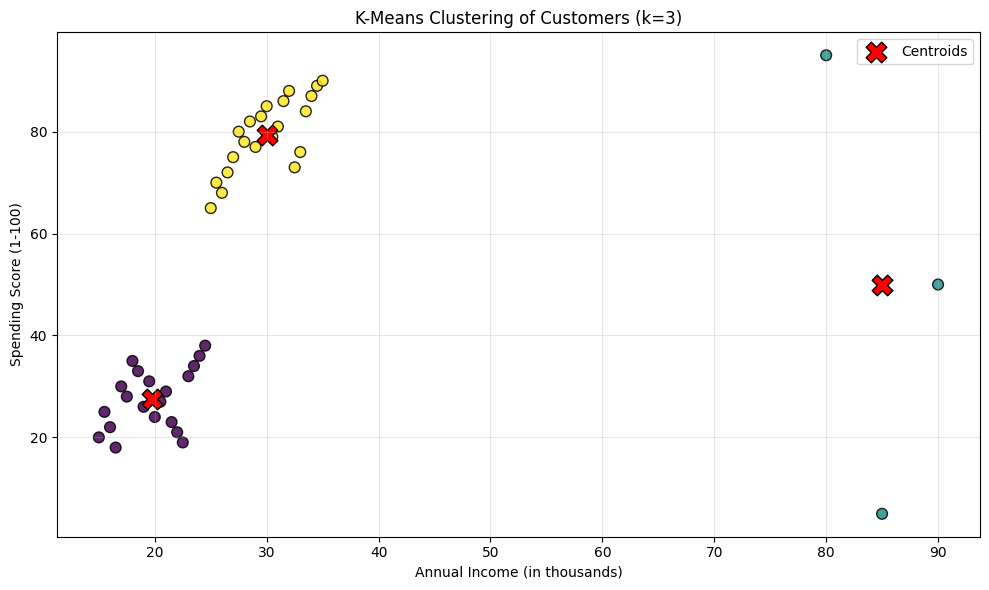

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    df['AnnualIncome'], df['SpendingScore'],
    c=df['Cluster'], cmap='viridis', s=60, edgecolor='k', alpha=0.85,
)

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(
    centers_original[:, 0], centers_original[:, 1],
    marker='X', s=220, c='red', edgecolor='black', label='Centroids',
)
ax.set_title('K-Means Clustering of Customers (k=3)')
ax.set_xlabel('Annual Income (in thousands)')
ax.set_ylabel('Spending Score (1-100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Elbow method — find the optimal k

Fit K-means for k = 1..10, plot the within-cluster sum of squares (WCSS). The 'elbow' is the point where adding another cluster stops meaningfully reducing WCSS.

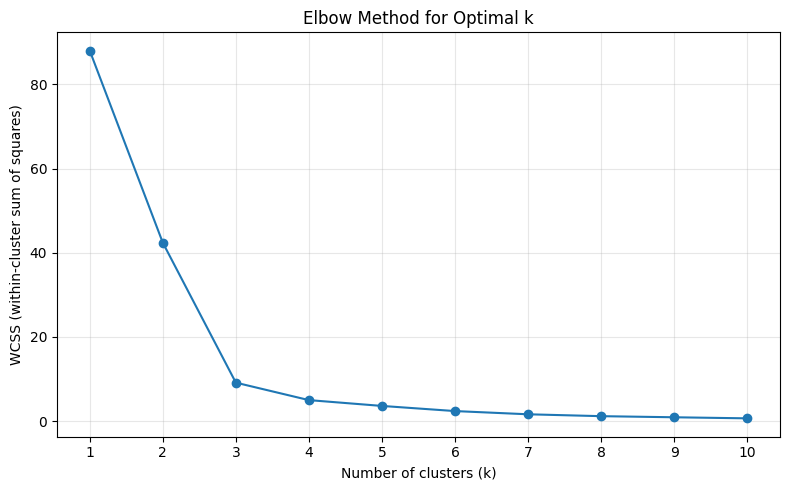

  k= 1  WCSS=88.0000
  k= 2  WCSS=42.3832
  k= 3  WCSS=9.1396
  k= 4  WCSS=4.9914
  k= 5  WCSS=3.6086
  k= 6  WCSS=2.3879
  k= 7  WCSS=1.6231
  k= 8  WCSS=1.1774
  k= 9  WCSS=0.9146
  k=10  WCSS=0.6605


In [6]:
wcss = []
ks = list(range(1, 11))
for i in ks:
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(df_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (within-cluster sum of squares)')
plt.xticks(ks)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for ki, w in zip(ks, wcss):
    print(f'  k={ki:2d}  WCSS={w:.4f}')

## 8. Interpret the clusters

Group means in original units tell the business story:

In [7]:
df.groupby('Cluster')[['AnnualIncome', 'SpendingScore']].mean().round(2)

,AnnualIncome,SpendingScore
Cluster,,
0,19.75,27.55
1,85.00,50.00
2,30.00,79.43


## Key takeaways

- **Always scale before K-means.** It minimizes Euclidean distance, so any feature with a larger range dominates without scaling.
- **`n_init=10`** (modern Scikit-learn default) restarts K-means with different centroid seeds and keeps the lowest-WCSS run — guards against bad initialization.
- **Elbow at k=3** matches the structure we built in: low-income low-spenders, low-income high-spenders, and high-income outliers. Big WCSS drop from k=2 (~42) to k=3 (~9), then much smaller drops after.
- The elbow method is a **heuristic** — pair it with silhouette score or business sense when the elbow isn't sharp.
- K-means assumes roughly **spherical, equally-sized** clusters. For arbitrarily-shaped or density-based clusters, **DBSCAN** is a better fit. The 3 outliers here happen to land in their own cluster, but that's not guaranteed — K-means doesn't have a notion of 'noise'.